In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
print(df.head(15))


    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0   Female  21.0    1.62    64.0                            yes   no   2.0   
1   Female  21.0    1.52    56.0                            yes   no   3.0   
2     Male  23.0    1.80    77.0                            yes   no   2.0   
3     Male  27.0    1.80    87.0                             no   no   3.0   
4     Male  22.0    1.78    89.8                             no   no   2.0   
5     Male  29.0    1.62    53.0                             no  yes   2.0   
6   Female  23.0    1.50    55.0                            yes  yes   3.0   
7     Male  22.0    1.64    53.0                             no   no   2.0   
8     Male  24.0    1.78    64.0                            yes  yes   3.0   
9     Male  22.0    1.72    68.0                            yes  yes   2.0   
10    Male  26.0    1.85   105.0                            yes  yes   3.0   
11  Female  21.0    1.72    80.0                            yes 

In [2]:
print(df.info())

# Gender -> płeć  |str  -> 0/1
# Age -> wiek
# Height -> wzrost
# Weight -> waga
# family_history_with_overweight -> czy w rodzinie występowała nadwaga/otyłość   |str  -> 0/1
# FAVC -> czy osoba często je wysokokaloryczne jedzenie   |str   -> 0/1
# FCVC -> częstotliwość jedzenia warzyw
# NCP -> liczba głównych posiłków dziennie
# CAEC -> podjadanie między posiłkami   |str -> ordinal ec
# SMOKE -> czy osoba pali     |str -> 0/1
# CH2O -> ilość wypijanej wody dziennie
# SCC -> czy osoba monitoruje spożywane kalorie | str  -> 0/1
# FAF -> poziom aktywności fizycznej
# TUE -> czas korzystania z urządzeń elektronicznych
# CALC -> częstotliwość spożywania alkoholu | str -> ordinal ec
# MTRANS -> główny środek transportu    |str -> one-hot ec
# NObeyesdad -> poziom otyłości / klasa docelowa | str -> ordinal ec

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

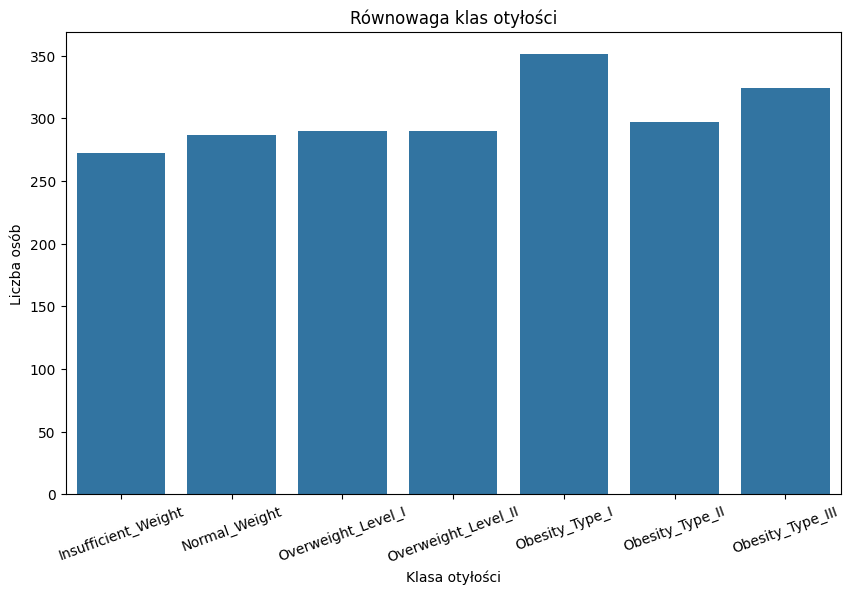

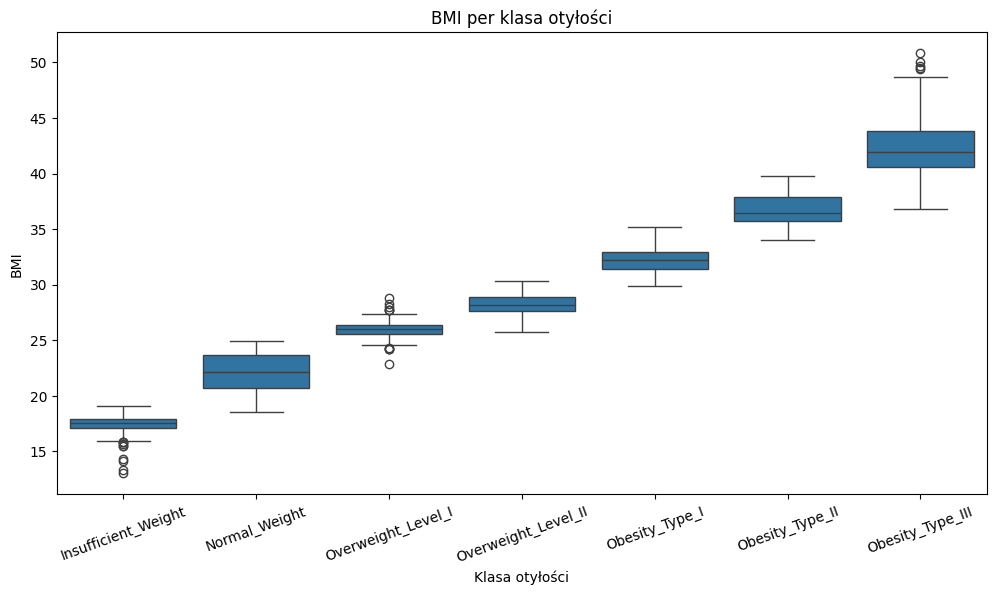

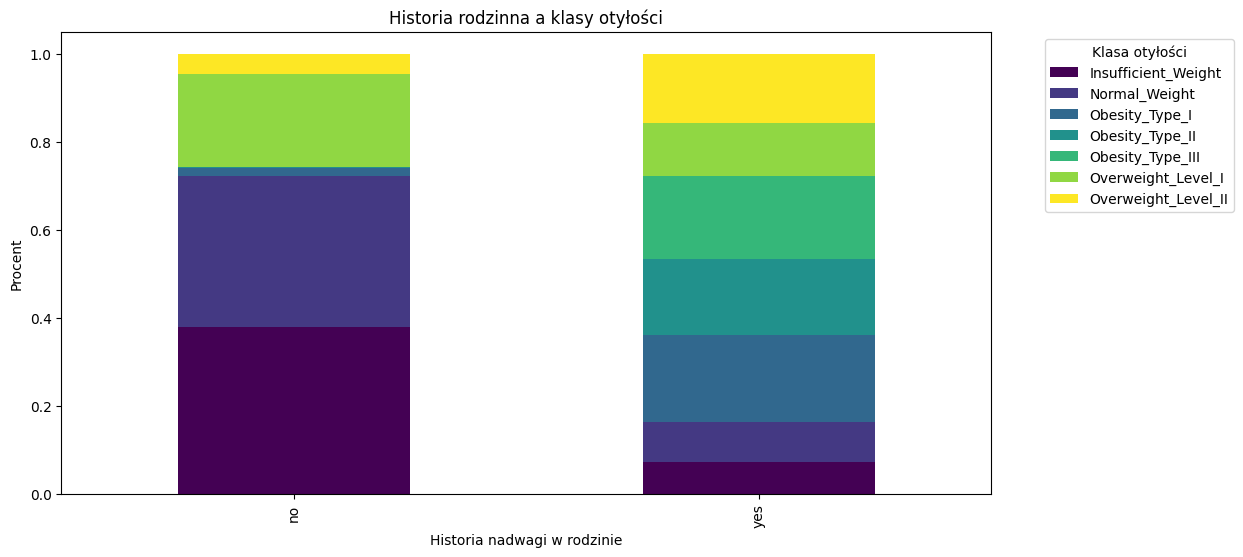

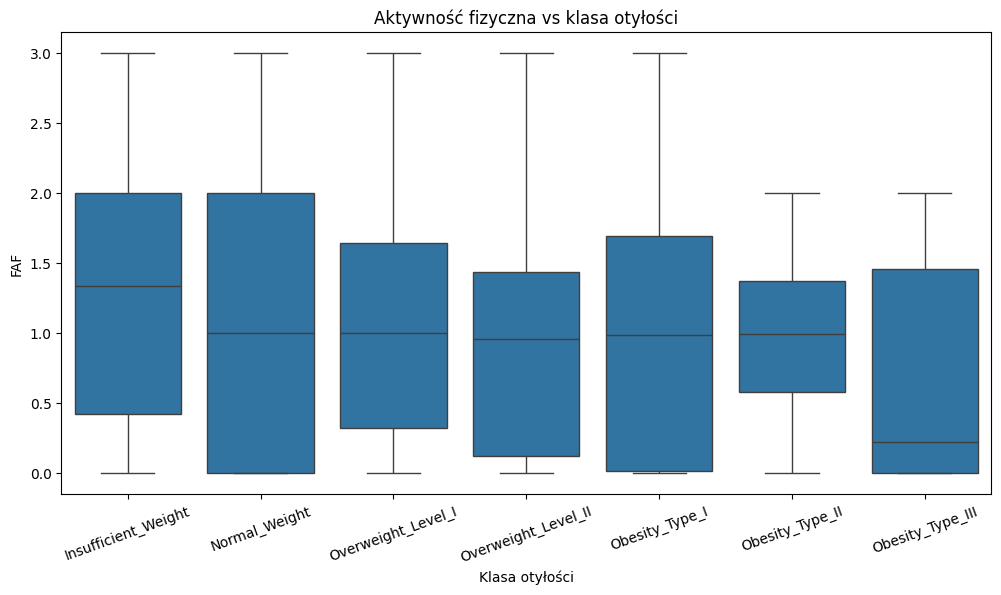

Braki danych:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
BMI                               0
dtype: int64

Duplikaty: 24

Liczba unikalnych wartości:
Gender                               2
SCC                                  2
SMOKE                                2
family_history_with_overweight       2
FAVC                                 2
CALC                                 4
CAEC                                 4
MTRANS  

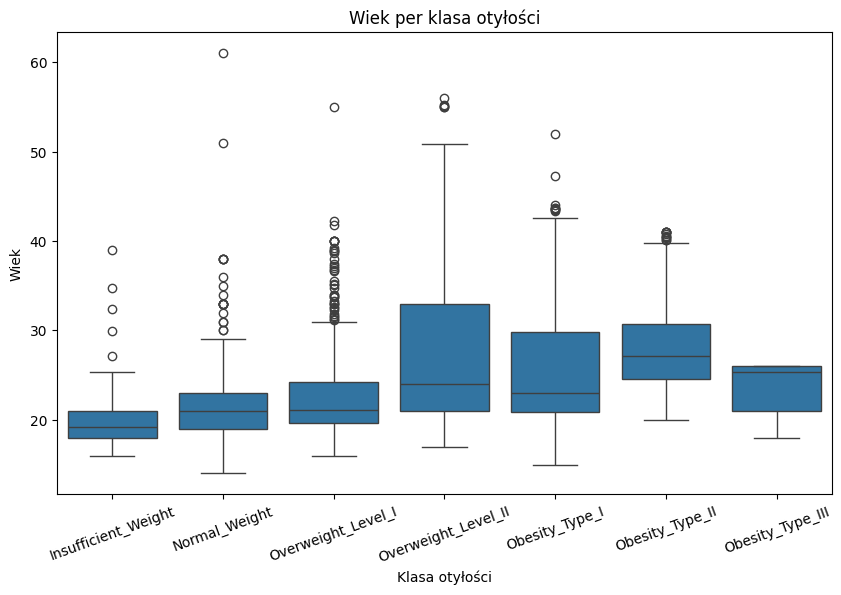

In [3]:
obesity_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

plt.figure(figsize=(10,6))
sns.countplot(data=df, x="NObeyesdad", order=obesity_order)

plt.title("Równowaga klas otyłości")
plt.xlabel("Klasa otyłości")
plt.ylabel("Liczba osób")
plt.xticks(rotation=20)
plt.show()

df["BMI"] = df["Weight"] / (df["Height"] ** 2)

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="NObeyesdad", y="BMI", order=obesity_order)

plt.title("BMI per klasa otyłości")
plt.xlabel("Klasa otyłości")
plt.ylabel("BMI")
plt.xticks(rotation=20)
plt.show()

family_obesity = pd.crosstab(
    df["family_history_with_overweight"],
    df["NObeyesdad"],
    normalize="index"
)

family_obesity.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="viridis"
)

plt.title("Historia rodzinna a klasy otyłości")
plt.xlabel("Historia nadwagi w rodzinie")
plt.ylabel("Procent")
plt.legend(title="Klasa otyłości", bbox_to_anchor=(1.05, 1))
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="NObeyesdad", y="FAF", order=obesity_order)

plt.title("Aktywność fizyczna vs klasa otyłości")
plt.xlabel("Klasa otyłości")
plt.ylabel("FAF")
plt.xticks(rotation=20)
plt.show()


print("Braki danych:")
print(df.isna().sum())

print("\nDuplikaty:", df.duplicated().sum())

print("\nLiczba unikalnych wartości:")
print(df.nunique().sort_values())

print("\nRozkład klas:")
print(df["NObeyesdad"].value_counts().reindex(obesity_order))

print("\nUdział klas:")
print((df["NObeyesdad"].value_counts(normalize=True).reindex(obesity_order) * 100).round(2))

print("\nKategorie rzadkie:")
for col in ["SMOKE", "SCC", "CALC", "MTRANS", "CAEC"]:
    print("\n", col)
    print(df[col].value_counts())

print("\nBMI według klas:")
print(df.groupby("NObeyesdad")["BMI"].describe().reindex(obesity_order))

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="NObeyesdad", y="Age", order=obesity_order)
plt.title("Wiek per klasa otyłości")
plt.xlabel("Klasa otyłości")
plt.ylabel("Wiek")
plt.xticks(rotation=20)
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
binary_map = {"yes": 1, "no": 0}
freq_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity_map = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6,
}

df_encoded = df.copy()
df_encoded["BMI"] = df_encoded["Weight"] / (df_encoded["Height"] ** 2)
df_encoded["Gender"] = df_encoded["Gender"].map({"Female": 0, "Male": 1})
df_encoded["family_history_with_overweight"] = df_encoded["family_history_with_overweight"].map(binary_map)
df_encoded["FAVC"]  = df_encoded["FAVC"].map(binary_map)
df_encoded["SMOKE"] = df_encoded["SMOKE"].map(binary_map)
df_encoded["SCC"]   = df_encoded["SCC"].map(binary_map)
df_encoded["CAEC"]  = df_encoded["CAEC"].map(freq_map)
df_encoded["CALC"]  = df_encoded["CALC"].map(freq_map)
df_encoded["NObeyesdad"] = df_encoded["NObeyesdad"].map(obesity_map)
df_encoded = pd.get_dummies(df_encoded, columns=["MTRANS"], drop_first=False, dtype=int)

df_encoded = df_encoded.drop_duplicates()

y = df_encoded["NObeyesdad"]
X = df_encoded.drop(columns=["NObeyesdad", "Height", "Weight"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

df_model = df_encoded.copy()

print("Train set:", X_train.shape)
print("Test set: ", X_test.shape)


Train set: (1669, 19)
Test set:  (418, 19)


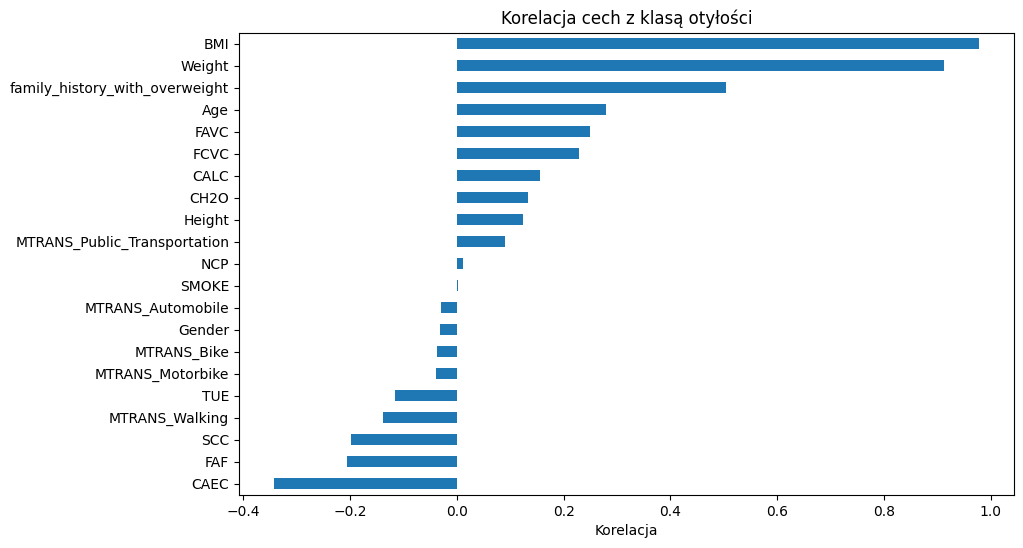

In [5]:
df_corr = df_model.copy()

corr = df_corr.corr()

target_corr = corr["NObeyesdad"].sort_values(ascending=False)


plt.figure(figsize=(10,6))

target_corr.drop("NObeyesdad").sort_values().plot(kind="barh")

plt.title("Korelacja cech z klasą otyłości")
plt.xlabel("Korelacja")
plt.show()


Train accuracy: 0.909
Test accuracy: 0.88
Train macro F1: 0.906
Test macro F1: 0.877
Balanced accuracy: 0.879
Średnia pewność: 0.755
Czas predykcji: 456 μs ± 32.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight      0.883     1.000     0.938        53
      Normal_Weight      0.938     0.789     0.857        57
 Overweight_Level_I      0.768     0.782     0.775        55
Overweight_Level_II      0.776     0.776     0.776        58
     Obesity_Type_I      0.910     0.871     0.891        70
    Obesity_Type_II      0.879     0.967     0.921        60
   Obesity_Type_III      1.000     0.969     0.984        65

           accuracy                          0.880       418
          macro avg      0.879     0.879     0.877       418
       weighted avg      0.883     0.880     0.880       418



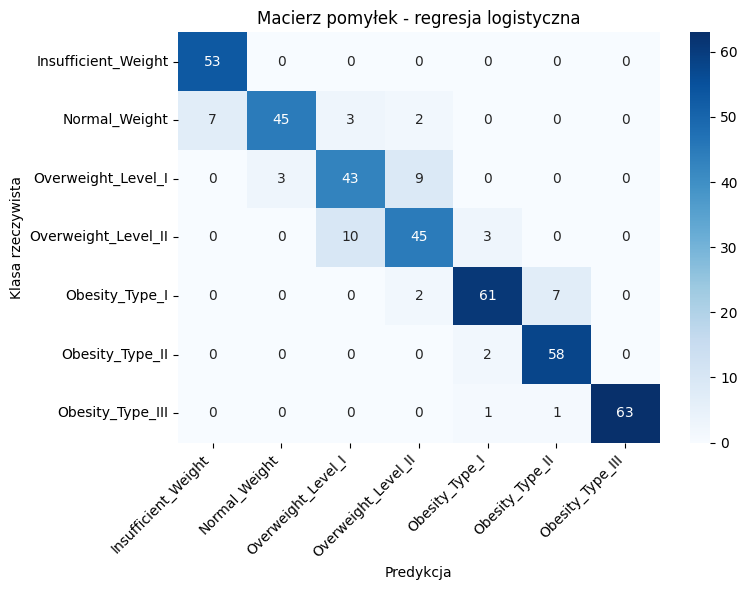

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

log_reg.fit(X_train, y_train)

inference_time = %timeit -o -q log_reg.predict(X_test)

y_train_pred = log_reg.predict(X_train)
y_test_pred  = log_reg.predict(X_test)
confidence   = log_reg.predict_proba(X_test).max(axis=1).mean()

print("Train accuracy:", round(accuracy_score(y_train, y_train_pred), 3))
print("Test accuracy:",  round(accuracy_score(y_test,  y_test_pred),  3))
print("Train macro F1:", round(f1_score(y_train, y_train_pred, average="macro"), 3))
print("Test macro F1:",  round(f1_score(y_test,  y_test_pred,  average="macro"), 3))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_test_pred), 3))
print("Średnia pewność:", round(confidence, 3))
print("Czas predykcji:", inference_time)

print("\nClassification report:")
print(classification_report(
    y_test, y_test_pred,
    labels=list(range(len(obesity_order))),
    target_names=obesity_order,
    digits=3,
    zero_division=0
))

plt.figure(figsize=(8,6))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred, labels=list(range(len(obesity_order)))),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=obesity_order,
    yticklabels=obesity_order
)
plt.title("Macierz pomyłek - regresja logistyczna")
plt.xlabel("Predykcja")
plt.ylabel("Klasa rzeczywista")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import precision_score, recall_score
import time

model_results = [
    {
        "model": "Regresja logistyczna",
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy":  accuracy_score(y_test,  y_test_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "macro_f1":        f1_score(y_test, y_test_pred, average="macro"),
        "macro_precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "macro_recall":    recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "confidence":      confidence,
        "prediction_time": inference_time.average,
    }
]

def evaluate_model(name, model):
    model.fit(X_train, y_train)

    timeit_result = %timeit -o -q model.predict(X_test)
    prediction_time = timeit_result.average

    y_pred = model.predict(X_test)
    y_train_pred_local = model.predict(X_train)

    if hasattr(model, "predict_proba"):
        conf = model.predict_proba(X_test).max(axis=1).mean()
    else:
        conf = np.nan

    result = {
        "model":            name,
        "train_accuracy":   accuracy_score(y_train, y_train_pred_local),
        "test_accuracy":    accuracy_score(y_test, y_pred),
        "balanced_accuracy":balanced_accuracy_score(y_test, y_pred),
        "macro_f1":         f1_score(y_test, y_pred, average="macro"),
        "macro_precision":  precision_score(y_test, y_pred, average="macro", zero_division=0),
        "macro_recall":     recall_score(y_test, y_pred, average="macro", zero_division=0),
        "confidence":       conf,
        "prediction_time":  prediction_time,
    }

    model_results.append(result)

    print(f"\n{'='*60}")
    print(f"  Model: {name}")
    print(f"{'='*60}")
    print(f"  Train accuracy:     {result['train_accuracy']:.3f}")
    print(f"  Test accuracy:      {result['test_accuracy']:.3f}")
    print(f"  Balanced accuracy:  {result['balanced_accuracy']:.3f}")
    print(f"  Macro F1:           {result['macro_f1']:.3f}")
    print(f"  Macro Precision:    {result['macro_precision']:.3f}")
    print(f"  Macro Recall:       {result['macro_recall']:.3f}")
    if not np.isnan(conf):
        print(f"  Srednia pewnosc:    {conf:.3f}")
    else:
        print("  Srednia pewnosc:    brak")
    print(f"  Czas predykcji:     {prediction_time:.5f} s")

    return model, y_pred


In [8]:
tree_shallow = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_deep = DecisionTreeClassifier(random_state=42)

tree_shallow, y_pred_tree_shallow = evaluate_model("Drzewo decyzyjne max_depth=4", tree_shallow)
tree_deep, y_pred_tree_deep = evaluate_model("Drzewo decyzyjne bez limitu głębokości", tree_deep)



  Model: Drzewo decyzyjne max_depth=4
  Train accuracy:     0.979
  Test accuracy:      0.969
  Balanced accuracy:  0.968
  Macro F1:           0.968
  Macro Precision:    0.969
  Macro Recall:       0.968
  Srednia pewnosc:    0.976
  Czas predykcji:     0.00033 s

  Model: Drzewo decyzyjne bez limitu głębokości
  Train accuracy:     1.000
  Test accuracy:      0.969
  Balanced accuracy:  0.968
  Macro F1:           0.968
  Macro Precision:    0.968
  Macro Recall:       0.968
  Srednia pewnosc:    1.000
  Czas predykcji:     0.00033 s


In [9]:
def make_bagging(estimator, n_estimators=30, bootstrap=True, bootstrap_features=False):
    try:
        return BaggingClassifier(
            estimator=estimator,
            n_estimators=n_estimators,
            bootstrap=bootstrap,
            bootstrap_features=bootstrap_features,
            random_state=42,
            n_jobs=-1
        )
    except TypeError:
        return BaggingClassifier(
            base_estimator=estimator,
            n_estimators=n_estimators,
            bootstrap=bootstrap,
            bootstrap_features=bootstrap_features,
            random_state=42,
            n_jobs=-1
        )

bagging_configs = [
    ("Bagging płytkie drzewa, 10 est.", DecisionTreeClassifier(max_depth=4, random_state=42), 10, True, False),
    ("Bagging płytkie drzewa, 50 est.", DecisionTreeClassifier(max_depth=4, random_state=42), 50, True, False),
    ("Bagging płytkie drzewa, bez bootstrap", DecisionTreeClassifier(max_depth=4, random_state=42), 50, False, False),
    ("Bagging głębokie drzewa, 50 est.", DecisionTreeClassifier(random_state=42), 50, True, False),
    ("Bagging płytkie drzewa, bootstrap_features", DecisionTreeClassifier(max_depth=4, random_state=42), 50, True, True),
    ("Bagging regresja logistyczna", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]), 30, True, False),
]

for name, estimator, n_estimators, bootstrap, bootstrap_features in bagging_configs:
    model = make_bagging(estimator, n_estimators, bootstrap, bootstrap_features)
    evaluate_model(name, model)



  Model: Bagging płytkie drzewa, 10 est.
  Train accuracy:     0.981
  Test accuracy:      0.971
  Balanced accuracy:  0.970
  Macro F1:           0.970
  Macro Precision:    0.972
  Macro Recall:       0.970
  Srednia pewnosc:    0.969
  Czas predykcji:     0.01710 s

  Model: Bagging płytkie drzewa, 50 est.
  Train accuracy:     0.982
  Test accuracy:      0.971
  Balanced accuracy:  0.970
  Macro F1:           0.970
  Macro Precision:    0.972
  Macro Recall:       0.970
  Srednia pewnosc:    0.948
  Czas predykcji:     0.02042 s

  Model: Bagging płytkie drzewa, bez bootstrap
  Train accuracy:     0.979
  Test accuracy:      0.969
  Balanced accuracy:  0.968
  Macro F1:           0.968
  Macro Precision:    0.969
  Macro Recall:       0.968
  Srednia pewnosc:    0.975
  Czas predykcji:     0.03022 s

  Model: Bagging głębokie drzewa, 50 est.
  Train accuracy:     1.000
  Test accuracy:      0.971
  Balanced accuracy:  0.969
  Macro F1:           0.970
  Macro Precision:    0.972
 

In [10]:
def make_adaboost(estimator, n_estimators=50, learning_rate=1.0):
    try:
        return AdaBoostClassifier(
            estimator=estimator,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=42
        )
    except TypeError:
        return AdaBoostClassifier(
            base_estimator=estimator,
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=42
        )

adaboost_configs = [
    ("AdaBoost płytkie drzewa (max_depth=2)", DecisionTreeClassifier(max_depth=2, random_state=42), 50, 1.0),
    ("AdaBoost płytkie drzewa, wolniejsze uczenie", DecisionTreeClassifier(max_depth=2, random_state=42), 100, 0.5),
    ("AdaBoost regresja logistyczna", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42), 50, 1.0),
]

X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled  = StandardScaler().fit(X_train).transform(X_test)

for name, estimator, n_estimators, learning_rate in adaboost_configs:
    model = make_adaboost(estimator, n_estimators, learning_rate)
    if "regresja logistyczna" in name:
        model.fit(X_train_scaled, y_train)
        timeit_result = %timeit -o -q model.predict(X_test_scaled)
        prediction_time = timeit_result.average
        y_pred = model.predict(X_test_scaled)
        y_train_pred_local = model.predict(X_train_scaled)
        conf = model.predict_proba(X_test_scaled).max(axis=1).mean() if hasattr(model, "predict_proba") else np.nan
        from sklearn.metrics import precision_score, recall_score
        result = {
            "model": name,
            "train_accuracy":   accuracy_score(y_train, y_train_pred_local),
            "test_accuracy":    accuracy_score(y_test, y_pred),
            "balanced_accuracy":balanced_accuracy_score(y_test, y_pred),
            "macro_f1":         f1_score(y_test, y_pred, average="macro"),
            "macro_precision":  precision_score(y_test, y_pred, average="macro", zero_division=0),
            "macro_recall":     recall_score(y_test, y_pred, average="macro", zero_division=0),
            "confidence":       conf,
            "prediction_time":  prediction_time,
        }
        model_results.append(result)
        print(f"\n{'='*60}")
        print(f"  Model: {name}")
        print(f"{'='*60}")
        print(f"  Train accuracy:     {result['train_accuracy']:.3f}")
        print(f"  Test accuracy:      {result['test_accuracy']:.3f}")
        print(f"  Balanced accuracy:  {result['balanced_accuracy']:.3f}")
        print(f"  Macro F1:           {result['macro_f1']:.3f}")
        if not np.isnan(conf):
            print(f"  Srednia pewnosc:    {conf:.3f}")
        print(f"  Czas predykcji:     {prediction_time:.5f} s")
    else:
        evaluate_model(name, model)

gradient_configs = [
    ("GradientBoosting 50 est., lr=0.1", 50, 0.1),
    ("GradientBoosting 100 est., lr=0.1", 100, 0.1),
    ("GradientBoosting 200 est., lr=0.05", 200, 0.05),
]

for name, n_estimators, learning_rate in gradient_configs:
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=42
    )
    evaluate_model(name, model)



  Model: AdaBoost płytkie drzewa (max_depth=2)
  Train accuracy:     0.974
  Test accuracy:      0.967
  Balanced accuracy:  0.965
  Macro F1:           0.965
  Macro Precision:    0.968
  Macro Recall:       0.965
  Srednia pewnosc:    0.153
  Czas predykcji:     0.00294 s

  Model: AdaBoost płytkie drzewa, wolniejsze uczenie
  Train accuracy:     0.974
  Test accuracy:      0.962
  Balanced accuracy:  0.961
  Macro F1:           0.961
  Macro Precision:    0.962
  Macro Recall:       0.961
  Srednia pewnosc:    0.155
  Czas predykcji:     0.00567 s

  Model: AdaBoost regresja logistyczna
  Train accuracy:     0.575
  Test accuracy:      0.565
  Balanced accuracy:  0.564
  Macro F1:           0.514
  Srednia pewnosc:    0.163
  Czas predykcji:     0.00026 s

  Model: GradientBoosting 50 est., lr=0.1
  Train accuracy:     1.000
  Test accuracy:      0.976
  Balanced accuracy:  0.975
  Macro F1:           0.975
  Macro Precision:    0.977
  Macro Recall:       0.975
  Srednia pewnosc: 

In [11]:
voting_model = VotingClassifier(
    estimators=[
        ("log_reg", log_reg),
        ("tree", DecisionTreeClassifier(max_depth=4, random_state=42)),
        ("gb", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ],
    voting="soft"
)

stacking_model = StackingClassifier(
    estimators=[
        ("tree", DecisionTreeClassifier(max_depth=4, random_state=42)),
        ("bagging", make_bagging(DecisionTreeClassifier(max_depth=4, random_state=42), n_estimators=30)),
        ("gb", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    n_jobs=-1
)

evaluate_model("Voting soft", voting_model)
evaluate_model("Stacking", stacking_model)



  Model: Voting soft
  Train accuracy:     0.996
  Test accuracy:      0.981
  Balanced accuracy:  0.980
  Macro F1:           0.980
  Macro Precision:    0.981
  Macro Recall:       0.980
  Srednia pewnosc:    0.894
  Czas predykcji:     0.00530 s

  Model: Stacking
  Train accuracy:     0.995
  Test accuracy:      0.976
  Balanced accuracy:  0.975
  Macro F1:           0.975
  Macro Precision:    0.976
  Macro Recall:       0.975
  Srednia pewnosc:    0.968
  Czas predykcji:     0.02384 s


(StackingClassifier(estimators=[('tree',
                                 DecisionTreeClassifier(max_depth=4,
                                                        random_state=42)),
                                ('bagging',
                                 BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=4,
                                                                                    random_state=42),
                                                   n_estimators=30, n_jobs=-1,
                                                   random_state=42)),
                                ('gb',
                                 GradientBoostingClassifier(random_state=42))],
                    final_estimator=LogisticRegression(class_weight='balanced',
                                                       max_iter=2000,
                                                       random_state=42),
                    n_jobs=-1),
 array([6, 4, 5, 6, 0, 1, 4, 1, 5, 6, 5, 1, 6, 5,


=== PORÓWNANIE WSZYSTKICH MODELI ===

                                      Model  Train acc  Test acc  Bal. acc  Macro F1 Pewność Czas pred. [s]
                                Voting soft      0.996     0.981     0.980     0.980   0.894        0.00500
         GradientBoosting 200 est., lr=0.05      1.000     0.981     0.980     0.980   0.992        0.00800
          GradientBoosting 100 est., lr=0.1      1.000     0.978     0.977     0.978   0.993        0.00400
           GradientBoosting 50 est., lr=0.1      1.000     0.976     0.975     0.975   0.985        0.00200
                                   Stacking      0.995     0.976     0.975     0.975   0.968        0.02400
 Bagging płytkie drzewa, bootstrap_features      0.982     0.974     0.972     0.972   0.745        0.02400
            Bagging płytkie drzewa, 10 est.      0.981     0.971     0.970     0.970   0.969        0.01700
            Bagging płytkie drzewa, 50 est.      0.982     0.971     0.970     0.970   0.948     

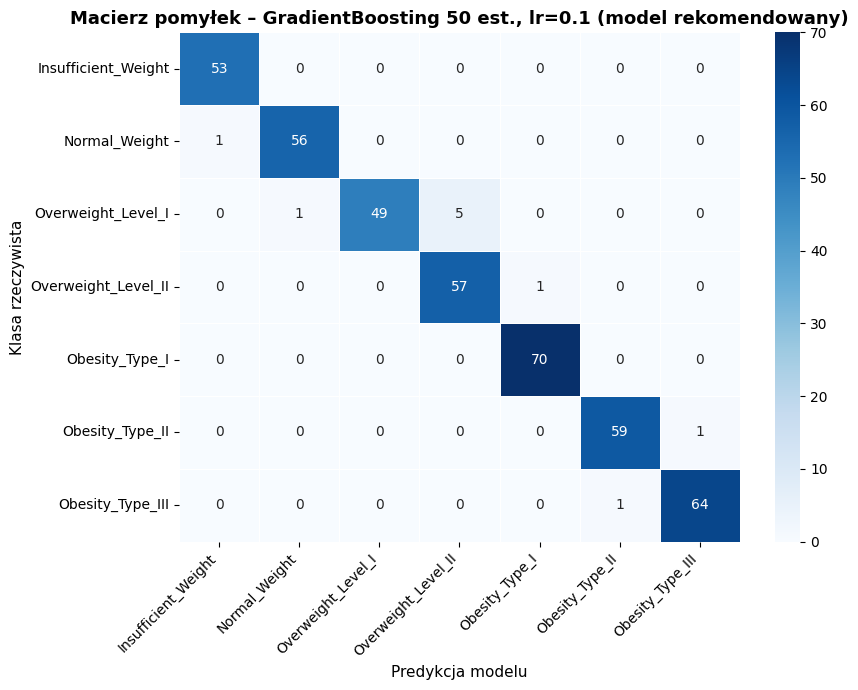

In [12]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by=["macro_f1", "balanced_accuracy", "prediction_time"],
    ascending=[False, False, True]
).reset_index(drop=True)

# ── Tabela porównawcza wszystkich modeli ──
display_df = results_df[["model", "train_accuracy", "test_accuracy",
                          "balanced_accuracy", "macro_f1",
                          "confidence", "prediction_time"]].copy()
display_df.columns = ["Model", "Train acc", "Test acc",
                      "Bal. acc", "Macro F1",
                      "Pewność", "Czas pred. [s]"]
display_df = display_df.round(3)
display_df["Czas pred. [s]"] = display_df["Czas pred. [s]"].map("{:.5f}".format)
display_df["Pewność"] = display_df["Pewność"].map(lambda x: f"{x:.3f}" if x == x else "—")

print("\n=== PORÓWNANIE WSZYSTKICH MODELI ===\n")
print(display_df.to_string(index=False))

# ── Macierz pomyłek – tylko rekomendowany model ──
best_model_name = "GradientBoosting 50 est., lr=0.1"
best_model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)
best_model.fit(X_train, y_train)
y_best_pred = best_model.predict(X_test)

print(f"\n\nClassification report – {best_model_name}:")
print(classification_report(
    y_test, y_best_pred,
    labels=list(range(len(obesity_order))),
    target_names=obesity_order,
    digits=3,
    zero_division=0
))

plt.figure(figsize=(9, 7))
sns.heatmap(
    confusion_matrix(y_test, y_best_pred, labels=list(range(len(obesity_order)))),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=obesity_order,
    yticklabels=obesity_order,
    linewidths=0.5
)
plt.title(f"Macierz pomyłek – {best_model_name} (model rekomendowany)", fontsize=13, fontweight="bold")
plt.xlabel("Predykcja modelu", fontsize=11)
plt.ylabel("Klasa rzeczywista", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [13]:
# WNIOSKI:
#
# Bagging saturuje szybko – przy płytkich drzewach już 10 estymatorów daje
# tyle samo co 50, tylko wolniej. Głębokie drzewa w Baggingu overfittują
# pojedynczo, ale zespół to naprawia – wynik ten sam, koszt obliczeniowy wyższy.
# bootstrap_features daje najlepsze F1 w Baggingu, ale mocno spada pewność
# (0.745), co w zastosowaniu medycznym jest poważną wadą.
#
# AdaBoost + regresja logistyczna praktycznie nie działa (~losowy wynik).
# LR jest zbyt silnym modelem na rolę weak learnera – AdaBoost potrzebuje
# czegoś ledwo lepszego od losowania, a nie globalnej granicy liniowej.
#
# REKOMENDACJA: GradientBoosting (50 est., lr=0.1)
# Najlepszy F1, najkrótszy czas predykcji spośród topowych modeli
# i wysoka pewność (0.985) – lekarz widzi kiedy model jest pewny,
# a kiedy ostrożniej. Stacking daje podobny wynik, ale jest znacznie wolniejszy.
#
# Jeśli usuniemy BMI z danych, wyniki całości spadają –
# wtedy przewagę zyskuje GradientBoosting ze 100 estymatorami.